# Reward samples from physical robot interactions
See: https://www.tokic.com/the-crawling-robot/
![title](https://github.com/micheltokic/crawlingrobot/blob/master/hardware-robot-reward-model.png?raw=true)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Actions refer to columns in RewardModel 
UP = 0
RIGHT = 1
DOWN = 2
LEFT = 3
ACTIONS =          np.array([ UP,   RIGHT,   DOWN,   LEFT], dtype=int)
ACTIONS_READABLE =          ["UP", "RIGHT", "DOWN", "LEFT"]

In [2]:
###################################
## Definition of reward model
### (no need to do anything here!)
###################################

# grid size
ROWS = 5
COLS = 5

RewardModel = np.zeros((COLS, ROWS, len(ACTIONS)))

# 1. row (ACTIONS: UP, RIGHT, DOWN, LEFT)
RewardModel[0][0] = [  0,  0,  0,   0]
RewardModel[0][1] = [  0,  0,  0,   0]
RewardModel[0][2] = [  0,  0,  0,   0]
RewardModel[0][3] = [  0,  0,  0,   0]
RewardModel[0][4] = [  0,  0,  0,   0]
# 2.row
RewardModel[1][0] = [  0,  0,  0,   0]
RewardModel[1][1] = [  0,  0,  0,   0]
RewardModel[1][2] = [  0,  0,  0,   0]
RewardModel[1][3] = [  0,  0,  4,   0]
RewardModel[1][4] = [  0,  0,  6,   0]
#3. row
RewardModel[2][0] = [  0,  0,  9,   0]
RewardModel[2][1] = [  0,  0, 11,   0]
RewardModel[2][2] = [  0, 15,  0,   0]
RewardModel[2][3] = [ -3, 12, 17, -10]
RewardModel[2][4] = [ -4,  0, 16, -11]
#4. row
RewardModel[3][0] = [ -5, 17, 19,   0]
RewardModel[3][1] = [ -9, 17, 20,  -8]
RewardModel[3][2] = [-16, 13, 19, -12]
RewardModel[3][3] = [-18, 12, 23, -14]
RewardModel[3][4] = [-16,  0, 23, -18]
#5. row
RewardModel[4][0] = [ -8, 14,  0,   0]
RewardModel[4][1] = [-26, 16,  0,  -6]
RewardModel[4][2] = [-18,  9,  0, -14]
RewardModel[4][3] = [-26, 10,  0, -15]
RewardModel[4][4] = [-30,  0,  0, -15]

print (RewardModel)

[[[  0.   0.   0.   0.]
  [  0.   0.   0.   0.]
  [  0.   0.   0.   0.]
  [  0.   0.   0.   0.]
  [  0.   0.   0.   0.]]

 [[  0.   0.   0.   0.]
  [  0.   0.   0.   0.]
  [  0.   0.   0.   0.]
  [  0.   0.   4.   0.]
  [  0.   0.   6.   0.]]

 [[  0.   0.   9.   0.]
  [  0.   0.  11.   0.]
  [  0.  15.   0.   0.]
  [ -3.  12.  17. -10.]
  [ -4.   0.  16. -11.]]

 [[ -5.  17.  19.   0.]
  [ -9.  17.  20.  -8.]
  [-16.  13.  19. -12.]
  [-18.  12.  23. -14.]
  [-16.   0.  23. -18.]]

 [[ -8.  14.   0.   0.]
  [-26.  16.   0.  -6.]
  [-18.   9.   0. -14.]
  [-26.  10.   0. -15.]
  [-30.   0.   0. -15.]]]


In [7]:
####################################
# Implement ValueIteration function
####################################
def ValueIteration (R, maxIterations = 10000, theta = 0.000001, gamma=0.999):
    
    rows, cols = R.shape[0:2]
    
    V = np.zeros((rows, cols))
    pi = np.zeros((rows, cols), dtype=int)
    
    iteration = 0
    end = False
    while (end == False):
        
        error = 0
        iteration += 1
        
        for x in range( 0, cols):
            for y in np.arange (0, rows):
        
                bestNewV = -np.inf
                
                for action in ACTIONS:
                    newX = x
                    newY = y
                    reward = R[y][x][action]

                    ## TODO: Recompute newX/newY according to action to be evaluated
                    ##       => Forbid actions across grid boundaries!
                    if action == DOWN:
                        if (y+1) < rows:
                            newY = y+1
                        else:
                            continue
                    if action == UP:
                        if (y-1) >= 0:
                            newY = y-1
                        else:
                            continue
                    if action == RIGHT:
                        if (x+1) < cols:
                            newX = x+1 
                        else:   
                            continue
                    if action == LEFT:
                        if (x-1) >= 0:
                            newX = x-1
                        else:
                            continue


                    ## TODO:  recompute value of current state
                    newV = reward + gamma * V[newY][newX]
                    
                    ## TODO: memorize estimated best action and hightes V value in current state s
                    if newV > bestNewV:
                        bestNewV = newV
                        bestAction = action

                ## TODO: measure maximum value error in current iteration
                error = max (error, abs(V[y][x] - bestNewV))
                
                # update estimated state value and policy action
                V[y][x] = bestNewV
                pi[y][x] = bestAction
                
        ## TODO: check iteration termination
        if (error < theta) or (iteration >= maxIterations):
            end = True
            print ("Ending at iteration #%d" % iteration)
            print ("Cum. error = %f" % error)
    return V, pi, iteration, error

In [8]:
###################################
### Plot policy function
### (no need to do anything here!)
###################################
def plotPolicy (policy, gamma):

    cols, rows = policy.shape

    Y = np.arange (0, rows)
    X = np.arange (0, cols)
    YN, XN = np.meshgrid(Y, X)
    #print ("XN=%s" % XN)
    #print ("YN=%s" % YN)

    for row in np.arange(0, rows, 1):
        for col in X:

            toX = 0
            toY = 0

            action = policy[row][col]
            if action == UP:
                toY = -1
            elif action == DOWN:
                toY = +1
            elif action == RIGHT:
                toX = +1
            elif action == LEFT:
                toX = -1

            ## TODO: Adapt for x/y boundaries - is there anything to do here?
            XN[row][col] = toX
            YN[row][col] = toY
        print("")
    
    fig, ax = plt.subplots()
    q = ax.quiver(X, Y, XN, YN, angles="xy")
    plt.xlabel ("x")
    plt.ylabel ("y")
    plt.xticks(np.arange(0, 5, 1))
    plt.yticks(np.arange(0, 5, 1))
    plt.title ("gamma=%.3f" % gamma)
    
    ## reverse Y-axis => in order that plot fits to above image
    plt.gca().invert_yaxis()  
    ## move x labels to top of plot
    ax.xaxis.tick_top()
    
    plt.show()

Ending at iteration #699
Cum. error = 0.000010
V=[[579.04751078 573.25703568 567.52446532 561.84922067 556.23072846]
 [584.8964853  579.04752045 573.25704524 567.52447479 561.84923004]
 [590.80453915 584.89649376 579.04752882 563.25705353 552.23073774]
 [587.68136224 576.44582882 558.68137053 539.80115683 530.70843036]
 [573.80454862 562.06650313 542.4458381  522.02137972 501.80116592]]
policy (numeric)=
[[2 2 2 2 2]
 [2 2 2 3 3]
 [2 3 3 3 0]
 [1 2 3 2 0]
 [0 3 3 3 3]]
policy (readable)=
[['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'LEFT' 'LEFT']
 ['DOWN' 'LEFT' 'LEFT' 'LEFT' 'UP']
 ['RIGHT' 'DOWN' 'LEFT' 'DOWN' 'UP']
 ['UP' 'LEFT' 'LEFT' 'LEFT' 'LEFT']]







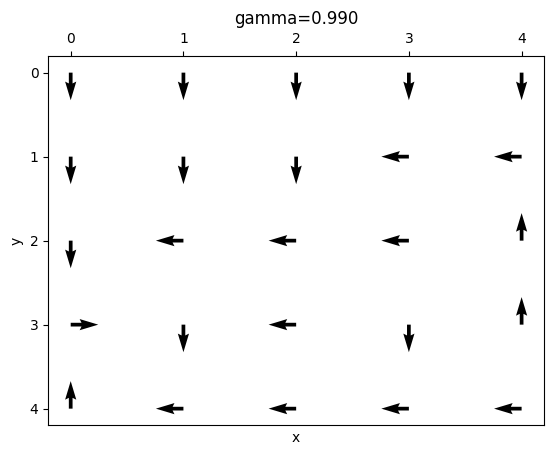

In [9]:
#################################################
### Learn and plot policy for given R and gamma
#################################################
# Run value iteration
gamma = 0.99
V, policy, iteration, error = ValueIteration(R=RewardModel, gamma=gamma, theta=0.00001, maxIterations=10000)
print ("V=%s" % V)

# construct array with readable actions
print ("policy (numeric)=\n%s" % policy)
policyReadable = np.array([[ACTIONS_READABLE[int(e)] for e in sub] for sub in policy])
print ("policy (readable)=\n%s" % policyReadable)

# Plot policy
plotPolicy (policy=policy, gamma=gamma)

Ending at iteration #2
Cum. error = 0.000000
reward: 
[]
Ending at iteration #8
Cum. error = 0.000001
reward: 
[5.0]
Ending at iteration #11
Cum. error = 0.000006
reward: 
[5.0, 5.0]
Ending at iteration #15
Cum. error = 0.000010
reward: 
[5.0, 5.0, 5.0]
Ending at iteration #25
Cum. error = 0.000005
reward: 
[5.0, 5.0, 5.0, 5.0]
Ending at iteration #36
Cum. error = 0.000007
reward: 
[5.0, 5.0, 5.0, 5.0, 5.0]
Ending at iteration #46
Cum. error = 0.000009
reward: 
[5.0, 5.0, 5.0, 5.0, 5.0, 19.0]
Ending at iteration #67
Cum. error = 0.000009
reward: 
[5.0, 5.0, 5.0, 5.0, 5.0, 19.0, 78.0]
Ending at iteration #699
Cum. error = 0.000010
reward: 
[5.0, 5.0, 5.0, 5.0, 5.0, 19.0, 78.0, 95.0]


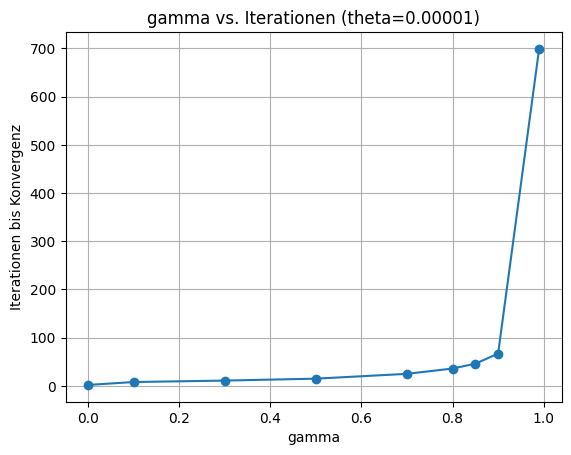

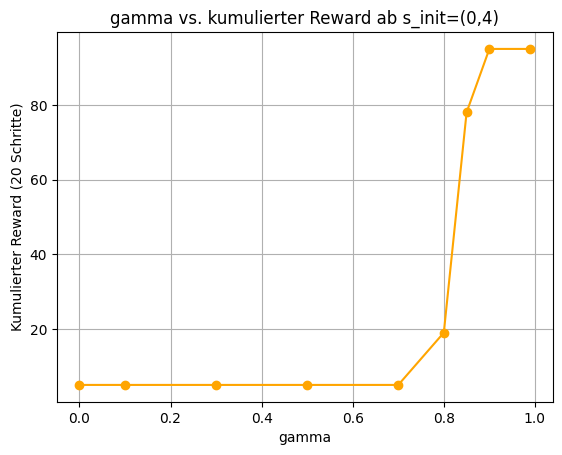

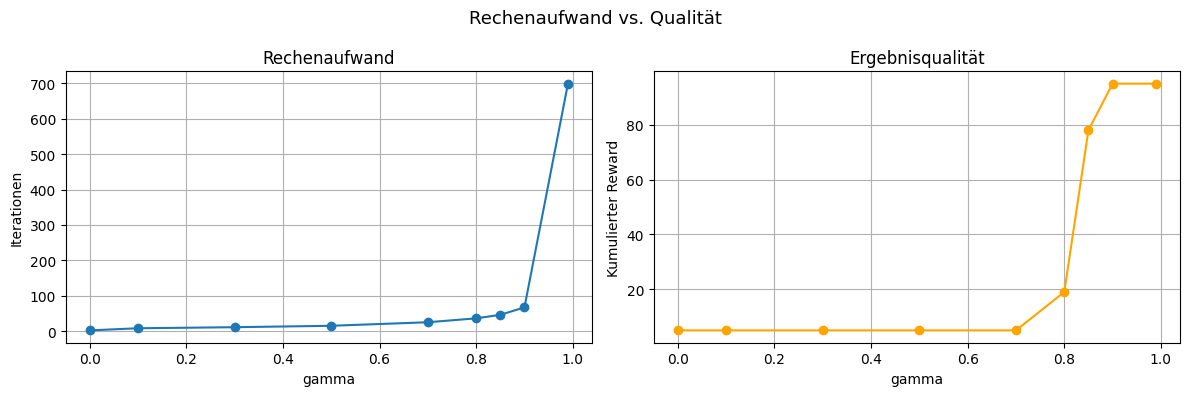

Optimales gamma=0.9 → Reward=95.0, Iterationen=67


In [ ]:
def simulate(policy, R, s_init, steps=20):
    y, x = s_init
    total_reward = 0
    for _ in range(steps):
        action = policy[y][x]
        total_reward += R[y][x][action]
        if action == UP:
            y = max(y - 1, 0)
        elif action == DOWN:
            y = min(y + 1, R.shape[0] - 1)
        elif action == RIGHT:
            x = min(x + 1, R.shape[1] - 1)
        elif action == LEFT:
            x = max(x - 1, 0)
    return total_reward

gammas = [0, 0.1, 0.3, 0.5, 0.7, 0.8, 0.85, 0.9, 0.99]
iterations_list = []
cumrewards_list = []

for gamma in gammas:
    V, policy, iteration, error = ValueIteration(R=RewardModel, gamma=gamma, theta=0.00001, maxIterations=10000)
    iterations_list.append(iteration)
    print("reward: ")
    print(cumrewards_list)
    cumrewards_list.append(simulate(policy=policy, R=RewardModel, s_init=(0, 4), steps=20))

#################################################
### 3.1 - Plot
#################################################
plt.figure()
plt.plot(gammas, iterations_list, marker='o')
plt.xlabel('gamma')
plt.ylabel('Iterationen bis Konvergenz')
plt.title('gamma vs. Iterationen (theta=0.00001)')
plt.grid(True)
plt.savefig("plot-3-1.pdf", format="pdf", bbox_inches="tight")
plt.show()

#################################################
### 3.2 - Plot
#################################################
plt.figure()
plt.plot(gammas, cumrewards_list, marker='o', color='orange')
plt.xlabel('gamma')
plt.ylabel('Kumulierter Reward (20 Schritte)')
plt.title('gamma vs. kumulierter Reward ab s_init=(0,4)')
plt.grid(True)
plt.savefig("plot-3-2.pdf", format="pdf", bbox_inches="tight")
plt.show()

#################################################
### 3.3 - Optimales gamma
#################################################
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(gammas, iterations_list, marker='o')
ax1.set_xlabel('gamma')
ax1.set_ylabel('Iterationen')
ax1.set_title('Rechenaufwand')
ax1.grid(True)
ax2.plot(gammas, cumrewards_list, marker='o', color='orange')
ax2.set_xlabel('gamma')
ax2.set_ylabel('Kumulierter Reward')
ax2.set_title('Ergebnisqualität')
ax2.grid(True)
plt.suptitle('Rechenaufwand vs. Qualität', fontsize=13)
plt.tight_layout()
plt.savefig("plot-3-3.pdf", format="pdf", bbox_inches="tight")
plt.show()

best_idx = np.argmax(cumrewards_list)
print(f"Optimales gamma={gammas[best_idx]} → Reward={cumrewards_list[best_idx]:.1f}, Iterationen={iterations_list[best_idx]}")

[0.0, 45.0, 45.0, 45.0, 45.0, 45.0, 45.0, 95.0, 95.0]
[0.0, 5.625, 5.0, 5.0, 5.0, 5.0, 5.0, 1.4615384615384615, 0.13590844062947066]


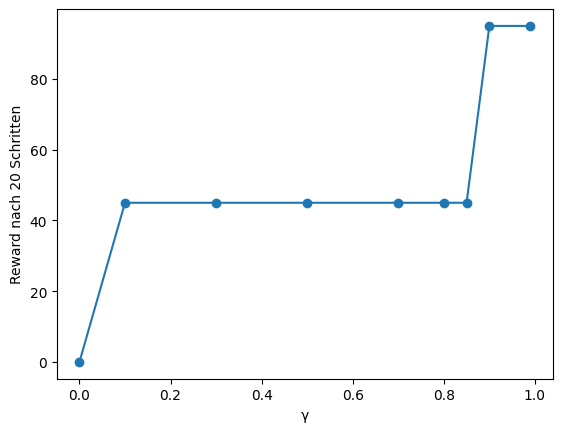

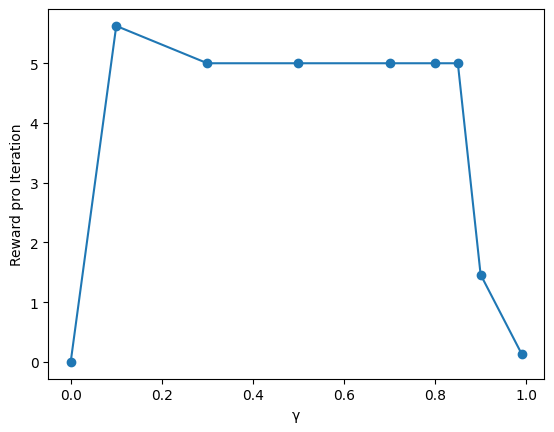

policy (numeric)=
[[2 2 2 2 2]
 [2 2 2 3 3]
 [2 3 3 3 0]
 [1 2 3 2 0]
 [0 3 3 3 3]]
policy (readable)=
[['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'LEFT' 'LEFT']
 ['DOWN' 'LEFT' 'LEFT' 'LEFT' 'UP']
 ['RIGHT' 'DOWN' 'LEFT' 'DOWN' 'UP']
 ['UP' 'LEFT' 'LEFT' 'LEFT' 'LEFT']]







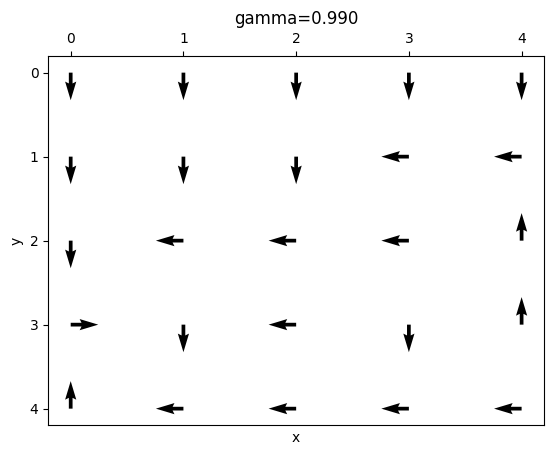

In [11]:
# 4. - Value Iteration with MDP Toolbox

from mdptoolbox.mdp import ValueIteration as MDPValueIteration

def our_index_to_mdptoolbox_index(x, y):
    return ROWS * x + y

S = 25
A = 4

# init transitions parameter
transitions = [np.zeros((S, S)) for _ in range(A)]
for action in ACTIONS:
    mat = transitions[action]
    for x in range(ROWS):
        for y in range(COLS):
            x_post, y_post = step(x, y, action)
            mat[our_index_to_mdptoolbox_index(x, y)][our_index_to_mdptoolbox_index(x_post, y_post)] = 1.0

# init reward parameter
reward = np.zeros((S, A))
for action in ACTIONS:
    for x in range(ROWS):
        for y in range(COLS):
            reward[our_index_to_mdptoolbox_index(x, y)][action] = RewardModel[y][x][action]

# init discount parameter
discount = 0.99

# init epsilon parameter
epsilon = 0.000001

# init max_iter parameter
max_iter = 10000

# call mdptoolbox value iteration
vi = MDPValueIteration(transitions = transitions, reward = reward, discount = discount, epsilon = epsilon, max_iter = max_iter)
vi.run()

# init final policy object
policy = np.zeros((ROWS, COLS), dtype=int)
for x in range(ROWS):
    for y in range(COLS):
        policy[y][x] = vi.policy[our_index_to_mdptoolbox_index(x, y)]

# construct array with readable actions
print ("policy (numeric)=\n%s" % policy)
policyReadable = np.array([[ACTIONS_READABLE[int(e)] for e in sub] for sub in policy])
print ("policy (readable)=\n%s" % policyReadable)

# Plot policy
plotPolicy (policy=policy, gamma=discount)

In [16]:
# 5 - Crawling Robot Value Iteration

import sys
import numpy as np
import pygame
import gymnasium as gym
import gym_crawlingrobot

# function maps the 2D observation (x, y) to a single state number n 
def obs_to_state(obs, obs_max):
    lower = obs[1]
    upper = obs[0]
    return int(upper * obs_max + lower)

def state_to_obs(state, obs_max):
    lower = state % obs_max
    upper = state // obs_max
    return (upper, lower)

# function that maps a 2D observation as x and y coordinates, together with an action, to the next state
def step_crawlingbot(state, action, obs_max) -> int:
    upper_arm, lower_arm = state_to_obs(state, obs_max)
    if action == DOWN:
        upper_arm = min(upper_arm + 1, obs_max - 1)
    if action == UP:
        upper_arm = max(upper_arm - 1, 0)
    if action == LEFT:
        lower_arm = min (lower_arm + 1, obs_max - 1)
    if action == RIGHT:
        lower_arm = max(lower_arm - 1, 0)
    return obs_to_state((upper_arm, lower_arm), obs_max)

def value_iteration_agent(obs_max, env, gamma, epsilon, episodes, maxSteps, render):
    episode_rewards = []
    episode_rewards_per_step = []
    np.set_printoptions(threshold=sys.maxsize)

    n_states = obs_max ** 2
    n_actions = env.action_space.n

    for episode in range (episodes):
        done = False
        init_obs, _ = env.reset()
        init_obs = init_obs.tolist()
        state = obs_to_state(init_obs, obs_max)
        step = 1
        cum_reward = 0

        # init value and reward functions for episode
        # reward function: function mapping (state, action) -> reward
        # one observation for each of the 2 arms
        R = np.zeros((n_states, n_actions))
        A = np.zeros((n_states, n_actions), dtype=int) # how often was action a taken in state s?
        V = np.zeros((n_states))

        while not done and step <= maxSteps:

            # action selection
            if np.random.rand() < epsilon: # random selection
                action = env.action_space.sample()
            else: # greedy selection
                # consistent with value iteration
                action_values = np.array([R[state][a] + gamma * V[step_crawlingbot(state, a, obs_max)] for a in range(n_actions)])
                # choose random action maximizing the value
                max_value_actions = np.flatnonzero(action_values == action_values.max())
                action = int(np.random.choice(max_value_actions))

            # perform action in environment
            nextObs, reward, terminated, truncated, _ = env.step(action)

            # update action counter
            A[state][action] += 1

            # update reward model
            # use mean of past rewards as per Sutton Reinforcement Learning 2.4 within an episode, adapt faster on a new episode due to step = 0 reset
            R[state][action] = R[state][action] + (reward - R[state][action])/(A[state][action])

            done = terminated or truncated
            nextObs = nextObs.tolist()
            nextState = obs_to_state(nextObs, obs_max)
            cum_reward += reward

            # environment rendering
            if render:
                env.render()

                # process pygame event loop
                for event in pygame.event.get():
                    if event.type == pygame.QUIT:
                        pygame.quit()
                        return
                    elif event.type == pygame.KEYDOWN:
                        if event.key == pygame.K_ESCAPE:
                            pygame.quit()
                            return
                        if event.key == pygame.K_SPACE:
                            env.robot.render_intermediate_steps = not env.robot.render_intermediate_steps

            # Value Iteration sweep
            for s in range(n_states):
                # calculate action maximizing expected reward
                action_values = np.array([R[s][a] + gamma * V[step_crawlingbot(s, a, obs_max)] for a in range(n_actions)])
                # update value function - this is in-place, which is guaranteed to converge by Sutton Reinforcement Learning, 4.4
                V[s] = action_values.max()

            # time transition
            state = nextState
            step += 1
            
        steps_taken = step - 1

        # update reward values
        episode_rewards.append(cum_reward)
        reward_per_step = cum_reward / steps_taken
        episode_rewards_per_step.append(reward_per_step)

        res = 0
        if len(env.unwrapped.robot.episode_time_results) > 0:
            res = env.unwrapped.robot.episode_time_results[-1]
        print(f"epsilon={epsilon} episode={episode} took {steps_taken - 1} steps => cumulative reward: {cum_reward:.2f}")
        
    pygame.quit()
    return (np.mean(episode_rewards), np.mean(episode_rewards_per_step))

pygame.quit() # close any already opened simulation windows

# instantiate environment
env = gym.make('crawlingrobot-discrete-v1', rotation_angles=5, goal_distance=700)

obs_max = env.observation_space.high[0] + 1  # currently 5

epsilons = np.linspace(0.0, 1.0, 15)

val_it_lam = lambda epsilon: value_iteration_agent(obs_max=obs_max, env=env, gamma=0.9, epsilon=epsilon, maxSteps=2000, episodes=100, render=False)
result = list(map(val_it_lam, epsilons))

pygame.quit() # close any already opened simulation windows

# extract mean rewards and rewards per step
mean_rewards, mean_rewards_per_step = zip(*result)

print("done!")
   

/Users/tommykiss/Desktop/Applied_Reinforcement_Learning/.venv/lib/python3.9/site-packages/gymnasium/envs/registration.py:487: UserWarning: WARN: The environment creator metadata doesn't include `render_modes`, contains: ['render.modes']
  )


epsilon=0.0 episode=0 took 199 steps => cumulative reward: 516.04
epsilon=0.0 episode=1 took 1999 steps => cumulative reward: 0.95
epsilon=0.0 episode=2 took 189 steps => cumulative reward: 512.48
epsilon=0.0 episode=3 took 420 steps => cumulative reward: 511.59
epsilon=0.0 episode=4 took 428 steps => cumulative reward: 514.24
epsilon=0.0 episode=5 took 1999 steps => cumulative reward: 0.95
epsilon=0.0 episode=6 took 1999 steps => cumulative reward: 0.95
epsilon=0.0 episode=7 took 1999 steps => cumulative reward: 0.95
epsilon=0.0 episode=8 took 1999 steps => cumulative reward: 0.95
epsilon=0.0 episode=9 took 428 steps => cumulative reward: 514.53
epsilon=0.0 episode=10 took 1999 steps => cumulative reward: 0.95
epsilon=0.0 episode=11 took 1999 steps => cumulative reward: 0.95
epsilon=0.0 episode=12 took 428 steps => cumulative reward: 514.53
epsilon=0.0 episode=13 took 428 steps => cumulative reward: 514.53
epsilon=0.0 episode=14 took 189 steps => cumulative reward: 512.48
epsilon=0.0 

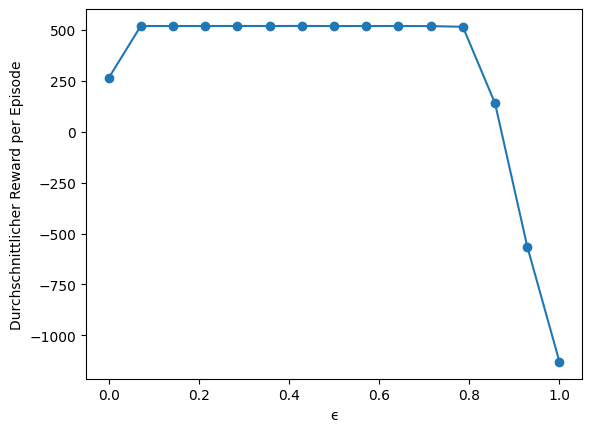

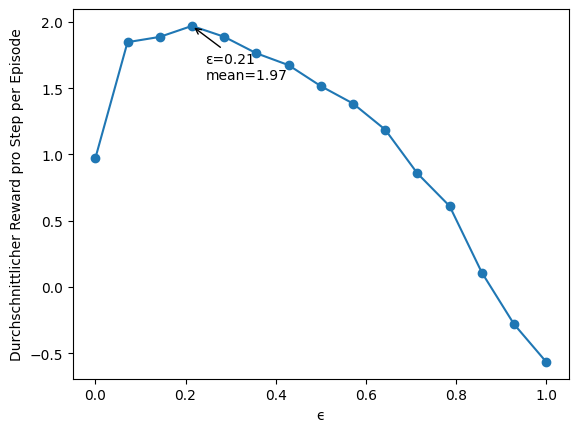

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt

# plot mean reward and reward per step depending on epsilon
fig, ax = plt.subplots()
ax.plot(epsilons, mean_rewards, marker='o')
ax.set_xlabel("ϵ")
ax.set_ylabel("Durchschnittlicher Reward per Episode")
plt.savefig("plot-5-1.pdf", format="pdf", bbox_inches="tight")
plt.show()

best_index = np.argmax(mean_rewards_per_step)
best_epsilon = epsilons[best_index]
best_value = mean_rewards_per_step[best_index]

fig, ax = plt.subplots()
ax.plot(epsilons, mean_rewards_per_step, marker='o')
ax.annotate(
    f"ε={best_epsilon:.2f}\nmean={best_value:.2f}",
    xy=(best_epsilon, best_value),
    xytext=(best_epsilon + 0.03, best_value - 0.4),
    arrowprops=dict(arrowstyle="->"),
)
ax.set_xlabel("ϵ")
ax.set_ylabel("Durchschnittlicher Reward pro Step per Episode")
plt.savefig("plot-5-2.pdf", format="pdf", bbox_inches="tight")
plt.show()